<div align="center">
  <img src="fotos/logo_utem.png" alt="Logo UTEM" width="120" style="max-height:140px; height:auto;"/>
  <br><br>
  <p style="margin:2px 0; font-size:16px; font-weight:400;">UNIVERSIDAD TECNOLOGICA METROPOLITANA</p>
  <p style="margin:2px 0; font-size:14px; font-weight:400;">INGENIERIA CIVIL EN CIENCIA DE DATOS</p>
  <p style="margin:2px 0; font-size:14px; font-weight:400;">INFB8090 - COMPUTACION PARALELA Y DISTRIBUIDA</p>
  <br><br>
  <h2 style="margin:0;">LABORATORIO N 5</h2>
  <br>
  <h1 style="margin:0;"><i>Comparativa de Rendimiento: CUDA vs OpenCL</i></h1>
  <br><br>
  <p style="margin:2px 0;">Profesor: Michael Miranda Sandoval</p>
  <p style="margin:2px 0;">Integrante: Diego Silva Madariaga/Pablo Ibañez</p>
  <p style="margin:2px 0;">Fecha: 04 de junio de 2026</p>
</div>

<div align="center">
  <p style="font-size:11px; color:#8a8a8a; margin:6px 0 0 0;">
    Equipo utilizado: AMD Ryzen 7 5700X | 16 GB RAM | NVIDIA GeForce RTX 4060
  </p>
</div>

Se comparo el rendimiento en la gpu con cuda y OpenCL. Para ello se implemento un ataque de fuerza bruta sobre hashes MD5, donde cada hilo de la GPU toma su identificador unico, lo convierte en una contraseña de texto corto en base 26 (letras minusculas a-z), calcula su hash MD5 y lo compara con un objetivo hardcodeado.

Se probaron tres longitudes de contraseña (4, 5 y 6 caracteres), lo que genera 457 mil, 11.9 millones y 308.9 millones de hilos respectivamente. Esto permite observar como escala el rendimiento de cada tecnologia a medida que aumenta la carga de trabajo.

Las metricas recolectadas son el tiempo de inicializacion, el tiempo de setup por ejecucion (alocacion de memoria y copia de datos al dispositivo), el tiempo de ejecucion del kernel en la GPU y el hashrate resultante en millones de hashes por segundo. Todos los datos se exportan a archivos CSV y se visualizan en este notebook.


- La version cuda lanza los hilos sobre la GPU donde cada hilo recibe su numero de identificacion global, lo convierte matematicamente en una contraseña de letras minusculas en base 26, calcula el hash MD5 de esa contrasena y lo compara con el objetivo. El tiempo de arranque del runtime se mide una sola vez al inicio, y por cada longitud de contraseña se mide por separado el tiempo de preparacion de memoria y el tiempo de ejecucion del kernel usando eventos internos de cuda.

- La version OpenCL hace exactamente lo mismo pero bajo una arquitectura diferente. El host en C++ se encarga de detectar la GPU disponible, crear el contexto de ejecucion y compilar el kernel en tiempo de ejecucion concatenando el archivo de implementacion MD5 con el archivo del kernel antes de enviarlo al compilador de la GPU. Una vez compilado, por cada longitud de contrasena se crean los buffers de memoria, se configuran los argumentos y se lanza el kernel midiendo su tiempo de ejecucion con el sistema de profiling propio de OpenCL.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

C_CUDA   = '#1B3A6B'   
C_OPENCL = '#4A90D9'   
C_ACCENT = '#A8C8F0'   
BG       = '#F7F9FC'

mpl.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': BG,
    'axes.facecolor': BG,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.edgecolor': '#CBD5E0',
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#CBD5E0',
    'grid.alpha': 0.6,
    'grid.linestyle': '--',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.labelcolor': '#2D3748',
    'xtick.color': '#4A5568',
    'ytick.color': '#4A5568',
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#CBD5E0',
})

cuda_df   = pd.read_csv('T5_resultados_cuda.csv')
opencl_df = pd.read_csv('T5_resultados_opencl.csv')
df = pd.concat([cuda_df, opencl_df], ignore_index=True)

init_df  = df[df['Longitud_Pass'] == 0].copy()
bench_df = df[df['Longitud_Pass'] >  0].copy()
cuda_b   = bench_df[bench_df['Tecnologia'] == 'CUDA']
opencl_b = bench_df[bench_df['Tecnologia'] == 'OpenCL']
lengths  = sorted(bench_df['Longitud_Pass'].unique())
x = np.arange(len(lengths))
w = 0.35

print("=== CUDA ===");   print(cuda_df.to_string(index=False))
print("\n=== OpenCL ==="); print(opencl_df.to_string(index=False))


=== CUDA ===
Tecnologia  Longitud_Pass  Hilos_Totales  Tiempo_Setup_ms  Tiempo_Kernel_ms  Hashrate_MHs
      CUDA              0              0           0.0154            0.0000          0.00
      CUDA              4         456976           0.1775            0.1679       2721.13
      CUDA              5       11881376           0.1162            1.6189       7338.97
      CUDA              6      308915776           0.1230           50.7136       6091.38

=== OpenCL ===
Tecnologia  Longitud_Pass  Hilos_Totales  Tiempo_Setup_ms  Tiempo_Kernel_ms  Hashrate_MHs
    OpenCL              0              0         114.9412            0.0000          0.00
    OpenCL              4         456976           0.0166            0.0870       5250.18
    OpenCL              5       11881376           0.0071            1.9005       6251.57
    OpenCL              6      308915776           0.0068           51.3393       6017.14


### Overhead de Inicialización

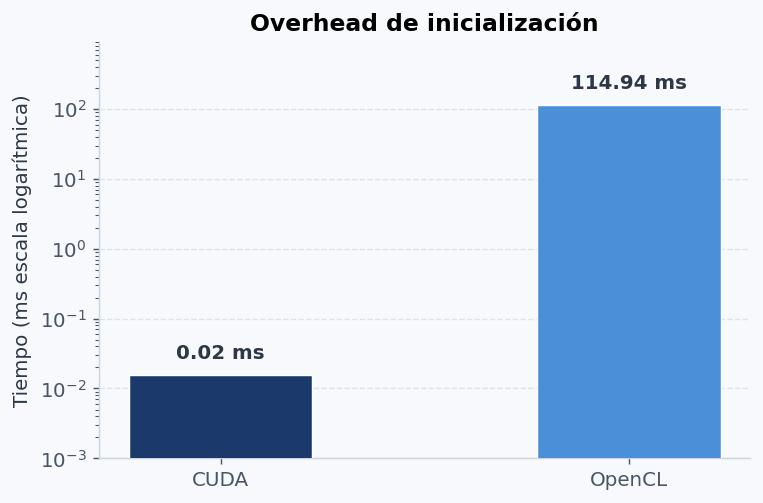

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor(BG)

techs = init_df['Tecnologia'].values
times = init_df['Tiempo_Setup_ms'].values

ax.set_yscale('log')
bars = ax.bar(techs, times, color=[C_CUDA, C_OPENCL], width=0.45,
              edgecolor='white', linewidth=0.8, zorder=3)
for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.5,
            f'{val:.2f} ms', ha='center', va='bottom', fontweight='bold',
            color='#2D3748', fontsize=11)
ax.set_ylabel('Tiempo (ms escala logarítmica)')
ax.set_title('Overhead de inicialización')
ax.set_ylim(0.001, max(times) * 8)
plt.tight_layout()
plt.savefig('T5_fig1_init.png', bbox_inches='tight', facecolor=BG)
plt.show()


Cuda tarda apenas 0.02ms en arrancar porque el codigo ya viene compilado para la GPU desde el momento en que se compila el programa. OpenCL en cambio tarda 114.94ms porque al ejecutarse lee los archivos fuente del kernel, los compila en ese momento para la GPU disponible y configura todo el entorno de ejecucion. Esta diferencia de mas de 5000 veces es el costo de la portabilidad que ofrece OpenCL frente a la especificidad de cuda.

### Tiempo de Setup por Longitud

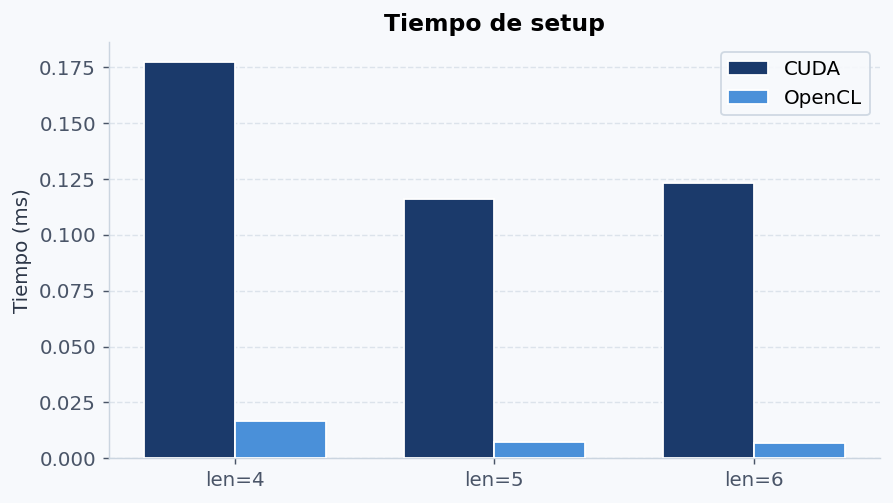

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor(BG)

cuda_s   = [cuda_b[cuda_b['Longitud_Pass']==l]['Tiempo_Setup_ms'].values[0]   for l in lengths]
opencl_s = [opencl_b[opencl_b['Longitud_Pass']==l]['Tiempo_Setup_ms'].values[0] for l in lengths]
b1 = ax.bar(x - w/2, cuda_s,   w, label='CUDA',   color=C_CUDA,   edgecolor='white', zorder=3)
b2 = ax.bar(x + w/2, opencl_s, w, label='OpenCL', color=C_OPENCL, edgecolor='white', zorder=3)
ax.set_xticks(x); ax.set_xticklabels([f'len={l}' for l in lengths])
ax.set_ylabel('Tiempo (ms)'); ax.set_title('Tiempo de setup')
ax.legend(); plt.tight_layout()
plt.savefig('T5_fig2_setup.png', bbox_inches='tight', facecolor=BG)
plt.show()


El tiempo de setup se encarga de medir cuanto tarda cada tecnologia en reservar memoria en la GPU y copiar los datos necesarios antes de lanzar el kernel. 

OpenCL es mas rapido en esta etapa, manteniendose por debajo de 0.02ms en todas las longitudes. cuda en cambio tarda entre 0.12ms y 0.18ms, lo que se explica porque cudaMalloc realiza mas trabajo interno de gestion de memoria que OpenCL. Estos tiempos son tan pequenos que en la practica no tienen impacto real sobre el rendimiento total.

### Tiempo de Ejecución del Kernel

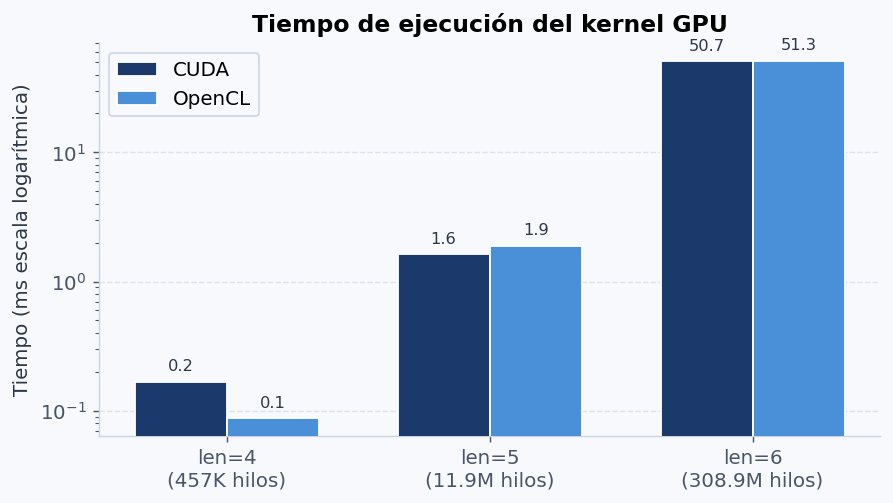

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor(BG)

cuda_k   = [cuda_b[cuda_b['Longitud_Pass']==l]['Tiempo_Kernel_ms'].values[0]   for l in lengths]
opencl_k = [opencl_b[opencl_b['Longitud_Pass']==l]['Tiempo_Kernel_ms'].values[0] for l in lengths]
b1 = ax.bar(x - w/2, cuda_k,   w, label='CUDA',   color=C_CUDA,   edgecolor='white', zorder=3)
b2 = ax.bar(x + w/2, opencl_k, w, label='OpenCL', color=C_OPENCL, edgecolor='white', zorder=3)
for bar, val in zip(list(b1)+list(b2), cuda_k+opencl_k):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9, color='#2D3748')

def fmt_hilos(l):
    n = 26**l
    return f'{n/1e6:.1f}M hilos' if n >= 1_000_000 else f'{n/1e3:.0f}K hilos'

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels([f'len={l}\n({fmt_hilos(l)})' for l in lengths])
ax.set_ylabel('Tiempo (ms escala logarítmica)')
ax.set_title('Tiempo de ejecución del kernel GPU')
ax.legend(); plt.tight_layout()
plt.savefig('T5_fig3_kernel.png', bbox_inches='tight', facecolor=BG)
plt.show()


El tiempo de ejecucion del kernel crece de forma clara a medida que aumenta el numero de hilos lo cual es esperado. Para len=6 con 308.9 millones de hilos ambas tecnologias son practicamente identicas. En len=4 con solo 457K hilos OpenCL aparece ligeramente mas rapido pero con tan pocos hilos la GPU no esta completamente saturada y las variaciones en esa escala no son significativas, una vez que la GPU trabaja a plena capacidad, el rendimiento bruto de cuda y OpenCL es equivalente sobre el mismo hardware.

### Throughput (Hashrate)

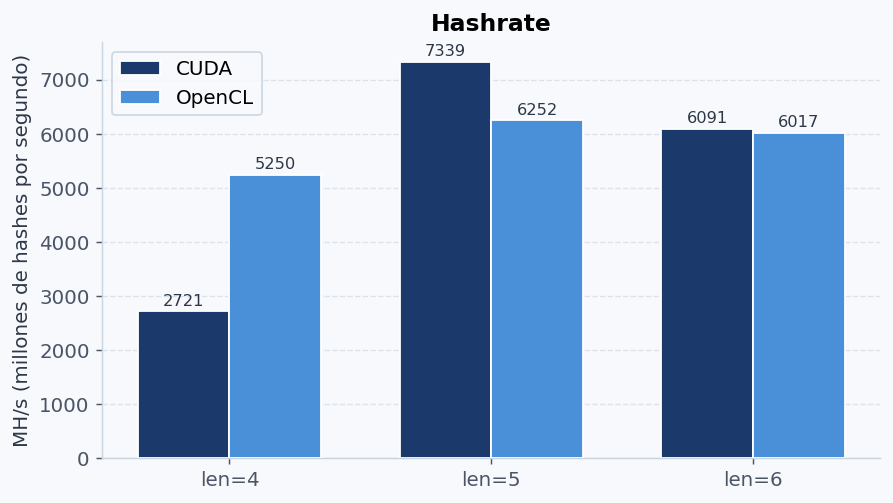

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor(BG)

cuda_h   = [cuda_b[cuda_b['Longitud_Pass']==l]['Hashrate_MHs'].values[0]   for l in lengths]
opencl_h = [opencl_b[opencl_b['Longitud_Pass']==l]['Hashrate_MHs'].values[0] for l in lengths]
b1 = ax.bar(x - w/2, cuda_h,   w, label='CUDA',   color=C_CUDA,   edgecolor='white', zorder=3)
b2 = ax.bar(x + w/2, opencl_h, w, label='OpenCL', color=C_OPENCL, edgecolor='white', zorder=3)
for bar, val in zip(list(b1)+list(b2), cuda_h+opencl_h):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:.0f}', ha='center', va='bottom', fontsize=9, color='#2D3748')
ax.set_xticks(x); ax.set_xticklabels([f'len={l}' for l in lengths])
ax.set_ylabel('MH/s (millones de hashes por segundo)'); ax.set_title('Hashrate')
ax.legend(); plt.tight_layout()
plt.savefig('T5_fig4_hashrate.png', bbox_inches='tight', facecolor=BG)
plt.show()


En len=4 cuda muestra un hashrate menor que OpenCL porque con solo 457K hilos no hay suficiente trabajo para mantener todos los cores de la GPU ocupados, y cuda tiene un overhead de lanzamiento ligeramente mayor en esa condicion. A partir de len=5 donde la GPU ya esta saturada cuda supera a OpenCL. En len=6 ambos convergen casi completamente confirmando que sobre el mismo hardware y con carga suficiente las dos tecnologias entregan un rendimiento bruto casi identico.

### Resumen Comparativo

In [12]:
rows = []
for l in lengths:
    ct = cuda_b[cuda_b['Longitud_Pass']==l]['Tiempo_Kernel_ms'].values[0]
    ot = opencl_b[opencl_b['Longitud_Pass']==l]['Tiempo_Kernel_ms'].values[0]
    ch = cuda_b[cuda_b['Longitud_Pass']==l]['Hashrate_MHs'].values[0]
    oh = opencl_b[opencl_b['Longitud_Pass']==l]['Hashrate_MHs'].values[0]
    rows.append({
        'Longitud': l,
        'Hilos': int(26**l),
        'Kernel CUDA (ms)':   round(ct, 3),
        'Kernel OpenCL (ms)': round(ot, 3),
        'CUDA MH/s':          round(ch, 1),
        'OpenCL MH/s':        round(oh, 1),
        'Speedup CUDA/OpenCL': round(ot/ct, 3) if ct > 0 else float('nan'),
    })
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))


 Longitud     Hilos  Kernel CUDA (ms)  Kernel OpenCL (ms)  CUDA MH/s  OpenCL MH/s  Speedup CUDA/OpenCL
        4    456976             0.168               0.087     2721.1       5250.2                0.518
        5  11881376             1.619               1.900     7339.0       6251.6                1.174
        6 308915776            50.714              51.339     6091.4       6017.1                1.012
